In [1]:
import pandas as pd
import numpy as np
print('Pandas is working perfectly fine')

Pandas is working perfectly fine


In [2]:
# Had some problems with the file path, as I was trying to use the CSV file on Codespaces. Importing file directly to the notebook.
import os 
file_name = "healthcare_dataset.csv"

#Learnt how to do a safety 'verification' as an exception handling method.
if os.path.exists(file_name):
    df = pd.read_csv(file_name)
    print("File read successfully")
else:
    print(f"Error not found {file_name}. in the directory.")

File read successfully


In [3]:
# I use this code to read the csv file and display the first 5 rows of the dataset to notice any immmediate issues with the data. I also use the str.title() method to capitalize the first letter of each word in the 'Name' column for better readability.
df = pd.read_csv("healthcare_dataset.csv")
df.head(5)

,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results
0,Bobby JacksOn,30,Male,B-,Cancer,31/01/2024,Matthew Smith,Sons and Miller,Blue Cross,18856.281306,328,Urgent,02/02/2024,Paracetamol,Normal
1,LesLie TErRy,62,Male,A+,Obesity,20/08/2019,Samantha Davies,Kim Inc,Medicare,33643.327287,265,Emergency,26/08/2019,Ibuprofen,Inconclusive
2,DaNnY sMitH,76,Female,A-,Obesity,22/09/2022,Tiffany Mitchell,Cook PLC,Aetna,27955.096079,205,Emergency,07/10/2022,Aspirin,Normal
3,andrEw waTtS,28,Female,O+,Diabetes,18/11/2020,Kevin Wells,"Hernandez Rogers and Vang,",Medicare,37909.782410,450,Elective,18/12/2020,Ibuprofen,Abnormal
4,adrIENNE bEll,43,Female,AB+,Cancer,19/09/2022,Kathleen Hanna,White-White,Aetna,14238.317814,458,Urgent,09/10/2022,Penicillin,Abnormal


In [4]:
print(df.columns.tolist())


['Name', 'Age', 'Gender', 'Blood Type', 'Medical Condition', 'Date of Admission', 'Doctor', 'Hospital', 'Insurance Provider', 'Billing Amount', 'Room Number', 'Admission Type', 'Discharge Date', 'Medication', 'Test Results']


In [5]:
#Then I use the str.title() method to capitalize the first letter of each word in the 'Name' column for better readability.
df['Name']=  df['Name'].str.title()
# Finally, I round the 'Billing Amount' column to 2 decimal places and rename it to 'Billing Amount ($)' for better clarity.
df = df.rename(columns={'Billing Amount': 'Billing Amount ($)'})
df['Billing Amount ($)'] = df['Billing Amount ($)'].round(2)
df.reset_index(drop=True, inplace=True)
df.head(5)

,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount ($),Room Number,Admission Type,Discharge Date,Medication,Test Results
0,Bobby Jackson,30,Male,B-,Cancer,31/01/2024,Matthew Smith,Sons and Miller,Blue Cross,18856.28,328,Urgent,02/02/2024,Paracetamol,Normal
1,Leslie Terry,62,Male,A+,Obesity,20/08/2019,Samantha Davies,Kim Inc,Medicare,33643.33,265,Emergency,26/08/2019,Ibuprofen,Inconclusive
2,Danny Smith,76,Female,A-,Obesity,22/09/2022,Tiffany Mitchell,Cook PLC,Aetna,27955.10,205,Emergency,07/10/2022,Aspirin,Normal
3,Andrew Watts,28,Female,O+,Diabetes,18/11/2020,Kevin Wells,"Hernandez Rogers and Vang,",Medicare,37909.78,450,Elective,18/12/2020,Ibuprofen,Abnormal
4,Adrienne Bell,43,Female,AB+,Cancer,19/09/2022,Kathleen Hanna,White-White,Aetna,14238.32,458,Urgent,09/10/2022,Penicillin,Abnormal


In [6]:
df= df[df['Test Results']!= 'Inconclusive']
df.head(5)

,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount ($),Room Number,Admission Type,Discharge Date,Medication,Test Results
0,Bobby Jackson,30,Male,B-,Cancer,31/01/2024,Matthew Smith,Sons and Miller,Blue Cross,18856.28,328,Urgent,02/02/2024,Paracetamol,Normal
2,Danny Smith,76,Female,A-,Obesity,22/09/2022,Tiffany Mitchell,Cook PLC,Aetna,27955.10,205,Emergency,07/10/2022,Aspirin,Normal
3,Andrew Watts,28,Female,O+,Diabetes,18/11/2020,Kevin Wells,"Hernandez Rogers and Vang,",Medicare,37909.78,450,Elective,18/12/2020,Ibuprofen,Abnormal
4,Adrienne Bell,43,Female,AB+,Cancer,19/09/2022,Kathleen Hanna,White-White,Aetna,14238.32,458,Urgent,09/10/2022,Penicillin,Abnormal
5,Emily Johnson,36,Male,A+,Asthma,20/12/2023,Taylor Newton,Nunez-Humphrey,UnitedHealthcare,48145.11,389,Urgent,24/12/2023,Ibuprofen,Normal


In [7]:
#Did this to find out the summary statistics of the dataset, such as the mean, standard deviation, minimum and maximum values, and quartiles. This information can help me understand the distribution of the data and identify any potential outliers or anomalies.
df.describe

<bound method NDFrame.describe of                     Name  Age  Gender Blood Type Medical Condition  \
0          Bobby Jackson   30    Male         B-            Cancer   
2            Danny Smith   76  Female         A-           Obesity   
3           Andrew Watts   28  Female         O+          Diabetes   
4          Adrienne Bell   43  Female        AB+            Cancer   
5          Emily Johnson   36    Male         A+            Asthma   
...                  ...  ...     ...        ...               ...   
55495  Elizabeth Jackson   42  Female         O+            Asthma   
55496         Kyle Perez   61  Female        AB-           Obesity   
55497       Heather Wang   38  Female         B+      Hypertension   
55498     Jennifer Jones   43    Male         O-         Arthritis   
55499       James Garcia   53  Female         O+         Arthritis   

      Date of Admission            Doctor                      Hospital  \
0            31/01/2024     Matthew Smith         

In [8]:
df['Medical Condition'].value_counts()
# I noticed that diabetes is the most common medical condition, so I checked the mean billing amount for patients in descending order
df.groupby('Medical Condition')['Billing Amount ($)'].mean().sort_values(ascending=False)
# I then created a new dataframe to display the mean billing amount for each medical condition in descending order, as well as the frequency of each condition via joining.
mean_count = pd.DataFrame(df.groupby('Medical Condition')['Billing Amount ($)'].mean().sort_values(ascending=False)).rename(columns={'Billing Amount ($)':'Mean Billing Amount'}).join(df['Medical Condition'].value_counts()).rename(columns={'count':'Number of Patients'})
print('Average Billing Amount and Number of Patients for each Medical Condition:')
mean_count


Average Billing Amount and Number of Patients for each Medical Condition:


,Mean Billing Amount,Number of Patients
Medical Condition,,
Obesity,25825.923219,6189
Arthritis,25593.148593,6220
Diabetes,25548.482477,6258
Asthma,25534.237856,6156
Hypertension,25313.345427,6154
Cancer,25167.524730,6167


In [9]:
#To look for correlation between blood type and medical condition, I created a new dataframe to display the mean billing amount for each medical condition in descending order, as well as the frequency of each condition via joining.
blood_count=pd.DataFrame(mean_count.join(df.groupby('Medical Condition')['Blood Type'].value_counts().rename('Blood Type Count'), how='right'))
blood_count.head()

Mean Billing Amount  Number of Patients  \
Medical Condition Blood Type                                            
Arthritis         AB-                25593.148593                6220   
                  O+                 25593.148593                6220   
                  B-                 25593.148593                6220   
                  B+                 25593.148593                6220   
                  O-                 25593.148593                6220   

                              Blood Type Count  
Medical Condition Blood Type                    
Arthritis         AB-                      830  
                  O+                       794  
                  B-                       794  
                  B+                       767  
                  O-                       766

In [10]:
#I wanted to remove the Number of Patients and the Mean Billing Amount column from the blood_count dataFrame.
blood_count=blood_count.drop(columns=['Mean Billing Amount']).drop(columns=['Number of Patients'])
blood_count.head(5)

Blood Type Count
Medical Condition Blood Type                  
Arthritis         AB-                      830
                  O+                       794
                  B-                       794
                  B+                       767
                  O-                       766

Hypothesis Testing: Analysing Blood Type against Medical Condition via Chi-Square
Now that I created blood_count, I will use the Chi-Squared test I learnt from school via the scipy library.
This is my hypotheses:
H0 : There is no correlation between the blood type of the patient and their illness.(They are independent)
H1: There is a correlation between the blood type of the patient and their illness.(They are dependent)
I will be using a 1% significance level, though I will compare with other significance levels later on.

In [11]:
# Had to sort a ModuleNotFoundError with scipy.stats in bash , but I managed to run the table!
import pandas as pd
from scipy.stats import chi2_contingency

contingency_table = pd.crosstab(df['Medical Condition'], df['Blood Type'])
print("Contingency Table between Medical Condition and Blood Type:")
print(contingency_table)

Contingency Table between Medical Condition and Blood Type:
Blood Type          A+   A-  AB+  AB-   B+   B-   O+   O-
Medical Condition                                        
Arthritis          746  763  760  830  767  794  794  766
Asthma             735  808  809  762  735  744  790  773
Cancer             809  739  702  830  800  769  736  782
Diabetes           809  817  761  750  792  784  806  739
Hypertension       748  786  823  733  727  790  775  772
Obesity            779  758  767  790  758  795  754  788


In [12]:
# Generated the required statistical values for the contingency table using the chi2_contingency function from scipy.stats.
chi2_stat, p_value, dof, expected = chi2_contingency(contingency_table)
print("\nStatistical Values:") #Learnt about newline character \n.
print(f"Chi-Squared Statistic: {chi2_stat:.3f}") # And learnt about 'f' to print variables in a string, and the :._f to round to _ decimal places.
print(f"P-Value: {p_value:.4f}")


Statistical Values:
Chi-Squared Statistic: 48.951
P-Value: 0.0589


Conclusion:
With a P-Value of 0.0589, or approximately 5.9%, it is above the 1% sig. level and is still non-significant at a 5% significance level. 
Thus, I must accept H0: There is indeed independence between the blood type and the patient's likelihood of getting a certain disease in this dataset.

In [13]:
avg_age=pd.DataFrame(df.groupby('Medical Condition')['Age'].mean().sort_values(ascending=False)).rename(columns={'Age':'Average Age'}).dropna()
avg_age['Average Age'] = avg_age['Average Age'].round(2) # Learnt about the round() function 
avg_age
# I realised that the average age of patients with medical conditions is roughly the same, at 51-52 years old.


,Average Age
Medical Condition,
Arthritis,51.64
Hypertension,51.60
Asthma,51.55
Cancer,51.45
Diabetes,51.32
Obesity,51.27


Normal Distribution of Age
I was curious to see how the age of patients would be distributed, since the mean is around 51-52. So, I studied the norm functions in the scipy library to form a normal distribution curve, then used matplotlib along with some np functions I already know to plot on those values to form a static image. Moreover, I wanted to show the mean and standard deviation as stand alone statistics, so I used the f...{._f} step I did in the chi-squared test.


In [14]:
mu = df['Age'].mean()
sigma = df['Age'].std()
df= df[(df['Age'] >=mu - 3*sigma) & (df['Age'] <=mu + 3*sigma)]
 # I used the 3-sigma rule to remove outliers from the Age column, as it is a common method for identifying and removing outliers in a dataset.

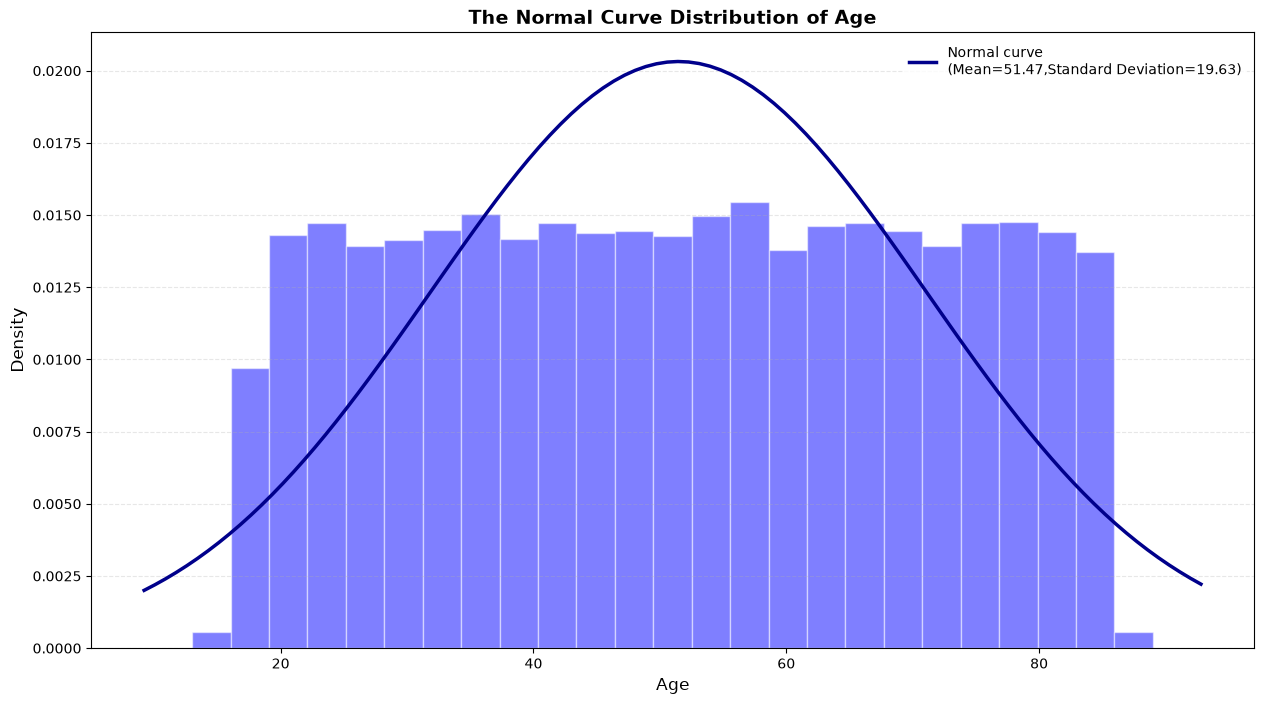

In [23]:
import matplotlib.pyplot as plt 
import numpy as np
from scipy.stats import norm 
%matplotlib inline
plt.figure(figsize=(15, 8))
mu = df['Age'].mean()
sigma = df['Age'].std()
plt.hist(df['Age'], bins=25, density=True, alpha=0.5, color='blue', edgecolor='white')
xmin, xmax = plt.xlim()
x=np.linspace(xmin, xmax, 100)
p= norm.pdf(x,mu, sigma)

plt.plot(x,p,color='darkblue', linewidth=2.5,label=f'Normal curve\n(Mean={mu:.2f},Standard Deviation={sigma:.2f})')
plt.title('The Normal Curve Distribution of Age',fontsize=14,fontweight='bold')
plt.xlabel('Age', fontsize=12)
plt.ylabel('Density', fontsize=12)
plt.grid(axis='y', linestyle='--',alpha=0.3)
plt.legend(frameon=True, facecolor='white', edgecolor="none")
plt.show()

At first, it looked like a perfect bell curve, but I wasn't so sure since patient age data is unlikely to create a perfect normal distribution. 
So I will do a Shapiro-Wilk test to see if the distribution is normal.

In [16]:
from scipy import stats 

data = df['Age']
stat,p_value = stats.shapiro(data)

print(f'Shapiro-Wilk Test Statistic: {stat:.4f}')
print(f'Shapiro-Wilk Test P-Value: {p_value:.4f}')
print('Shapiro-Wilk Test P-Value: {p_value:.4f}')

#I'm setting alpha to 0.05 for the significance level of the Shapiro-Wilk test. If the p-value is less than alpha, we reject the null hypothesis that the data is normally distributed.
alpha = 0.05
if p_value > alpha:
    print("Fail to reject the null hypothesis: The data is normally distributed.")
else:
    print("Reject the null hypothesis: The data is not normally distributed.")

Shapiro-Wilk Test Statistic: 0.9563
Shapiro-Wilk Test P-Value: 0.0000
Shapiro-Wilk Test P-Value: {p_value:.4f}
Reject the null hypothesis: The data is not normally distributed.


/workspaces/hospital_data_project/.venv/lib/python3.14/site-packages/scipy/stats/_axis_nan_policy.py:601: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 37144.
  res = hypotest_fun_out(*samples, **kwds)


From the value of the p-value, I assume that the data is too large for the Sharpiro-Wilks test to be accurate. According to the Central Limit Theorem I researched in Further Maths , since N>5000 and it looks like a bell curve, I will assume the distribution of patient's age is normal so that I can use it for future tests.(N=37144)

Anova Test: Does the Hospital patients seek treatment at have a significant difference on the time spent in the hospital?



In [17]:
df['Date of Admission']=pd.to_datetime(df['Date of Admission'],dayfirst=True)
df['Discharge Date'] =pd.to_datetime(df['Discharge Date'],dayfirst=True)
df['Days Spent'] = (df['Discharge Date'] - df['Date of Admission']).dt.days
df['Days Spent']=df['Days Spent'].astype(int).clip(lower=1) 
# I used the clip() method to set a lower limit of 1 for the 'Days Spent' column, as a patient who is admitted and discharged on the same day should be counted as having spent at least 1 day in the hospital.
means_table=df.groupby(df['Medical Condition'])['Days Spent'].mean()
days_total=means_table.to_frame(name='Mean Days Spent')
print("Mean Days Table: \n", days_total)
days= pd.DataFrame(df['Days Spent']).reset_index(drop=True)
days.head(5)







Mean Days Table: 
                    Mean Days Spent
Medical Condition                 
Arthritis                15.528778
Asthma                   15.596979
Cancer                   15.589914
Diabetes                 15.441675
Hypertension             15.482288
Obesity                  15.533366


,Days Spent
0,2
1,15
2,30
3,20
4,4


As the mean days for each disease spent are around 15-16 days, it is unlikely that the p-value would indicate that the mean days are stastically different and any slight difference would be due to chance.
So I would do the ANOVA test based on the most popular hospitals instead.

In [18]:
#I am checking the number and count of unique values in the 'Hospital' Table that had at least 15 patients in the dataset.
freq_hosp = df['Hospital'].value_counts()
freq_hosp = freq_hosp[freq_hosp >= 15] #I picked 15 as it was the mean number of patients per hospital in the dataset. This allows me to focus on hospitals with a significant number of patients, which can provide more reliable insights and reduce noise from hospitals with very few patients.
print(freq_hosp)
print(freq_hosp.describe())

Hospital
LLC Smith         31
Smith PLC         30
Smith Group       29
Ltd Smith         29
Smith Ltd         26
Johnson Inc       25
Smith LLC         23
PLC Williams      22
LLC Johnson       21
Group Smith       20
PLC Smith         20
Inc Jones         20
Brown Inc         20
Jones LLC         18
Johnson Group     17
Williams Group    17
Inc Smith         17
Johnson LLC       17
Jones Group       17
Group Johnson     17
Smith Inc         17
Brown Group       17
Johnson Ltd       17
Miller LLC        16
Anderson PLC      16
Williams LLC      16
Brown PLC         16
Ltd Brown         16
Johnson PLC       16
LLC Williams      16
Inc Brown         16
Jones Ltd         15
Brown LLC         15
Group Davis       15
LLC Brown         15
Brown Ltd         15
Name: count, dtype: int64
count    36.000000
mean     19.166667
std       4.693460
min      15.000000
25%      16.000000
50%      17.000000
75%      20.250000
max      31.000000
Name: count, dtype: float64


In [19]:
freq_hosp=pd.DataFrame(freq_hosp).rename(columns={'count':'Number of Patients'}).sort_values(by='Number of Patients',ascending=True)
freq_hosp = freq_hosp.drop(columns=['Mean Days Spent'], errors='ignore')
freq_hosp = freq_hosp.join(
    df.groupby('Hospital')['Days Spent'].mean().rename('Mean Days Spent')
)
freq_hosp['Mean Days Spent'] = freq_hosp['Mean Days Spent'].round(2)# I was struggling to round the mean days with the {:.f} format specifier, so I used the round() method instead to round the mean days spent to 2 decimal places.
freq_hosp.head()

,Number of Patients,Mean Days Spent
Hospital,,
Jones Ltd,15,15.93
LLC Brown,15,15.53
Group Davis,15,13.27
Brown LLC,15,15.40
Brown Ltd,15,15.47


Upon further inspection, I should do a oneway test instead of a twoway one, as the Hospital patients stay in might have a say in the days spent in the hospital, but the same cannot be said in reverse.
H0: The mean days spent is not statistically different across hospitals, and any difference is due to chance.
H1: The mean days spent is statistally diferent for at least one hospital.

In [20]:
df = df.reset_index(drop=True)
df.head()

,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount ($),Room Number,Admission Type,Discharge Date,Medication,Test Results,Days Spent
0,Bobby Jackson,30,Male,B-,Cancer,2024-01-31,Matthew Smith,Sons and Miller,Blue Cross,18856.28,328,Urgent,2024-02-02,Paracetamol,Normal,2
1,Danny Smith,76,Female,A-,Obesity,2022-09-22,Tiffany Mitchell,Cook PLC,Aetna,27955.10,205,Emergency,2022-10-07,Aspirin,Normal,15
2,Andrew Watts,28,Female,O+,Diabetes,2020-11-18,Kevin Wells,"Hernandez Rogers and Vang,",Medicare,37909.78,450,Elective,2020-12-18,Ibuprofen,Abnormal,30
3,Adrienne Bell,43,Female,AB+,Cancer,2022-09-19,Kathleen Hanna,White-White,Aetna,14238.32,458,Urgent,2022-10-09,Penicillin,Abnormal,20
4,Emily Johnson,36,Male,A+,Asthma,2023-12-20,Taylor Newton,Nunez-Humphrey,UnitedHealthcare,48145.11,389,Urgent,2023-12-24,Ibuprofen,Normal,4


In [21]:
anova_data= df[df['Hospital'].isin(freq_hosp.index)]
anova_data.head(5)
anova_data.info() # Has a sample size of 690 patients, which is a good sample size for statistical analysis.


<class 'pandas.DataFrame'>
Index: 690 entries, 14 to 37095
Data columns (total 16 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   Name                690 non-null    str           
 1   Age                 690 non-null    int64         
 2   Gender              690 non-null    str           
 3   Blood Type          690 non-null    str           
 4   Medical Condition   690 non-null    str           
 5   Date of Admission   690 non-null    datetime64[us]
 6   Doctor              690 non-null    str           
 7   Hospital            690 non-null    str           
 8   Insurance Provider  690 non-null    str           
 9   Billing Amount ($)  690 non-null    float64       
 10  Room Number         690 non-null    int64         
 11  Admission Type      690 non-null    str           
 12  Discharge Date      690 non-null    datetime64[us]
 13  Medication          690 non-null    str           
 14  Test Re

In [22]:
from scipy.stats import f_oneway
# I used the f_oneway function from scipy.stats to perform a one-way ANOVA test
